In [1]:
import numpy as np
import torch
import torchvision
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from torchsummary import summary
from torchvision import datasets, transforms

# Transfer ResNet

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [3]:
# ResNet is trained for images in a specific range

transformer = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

data_train = datasets.STL10(root='data', split="train", download=True, transform=transformer) 
data_test = datasets.STL10(root='data', split="test", download=True, transform=transformer)   

batch_size = 32
train_dataloader = DataLoader(data_train, batch_size=batch_size, shuffle=True, drop_last=True)
test_dataloader = DataLoader(data_test, batch_size=batch_size, shuffle=False)

images, labels = next(iter(train_dataloader))
print(f"Image batch shape: {images.shape}")
print(f"Label batch shape: {labels.shape}")
print(f"Data categories: {data_train.classes}")

Image batch shape: torch.Size([32, 3, 96, 96])
Label batch shape: torch.Size([32])
Data categories: ['airplane', 'bird', 'car', 'cat', 'deer', 'dog', 'horse', 'monkey', 'ship', 'truck']


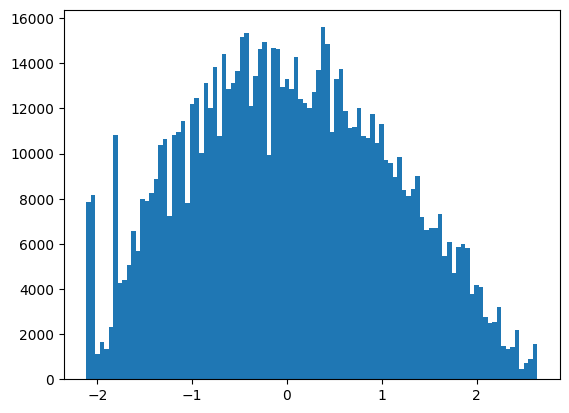

In [4]:
# pixel intensity values in the images
plt.hist(images.data.numpy().flatten(), 100);

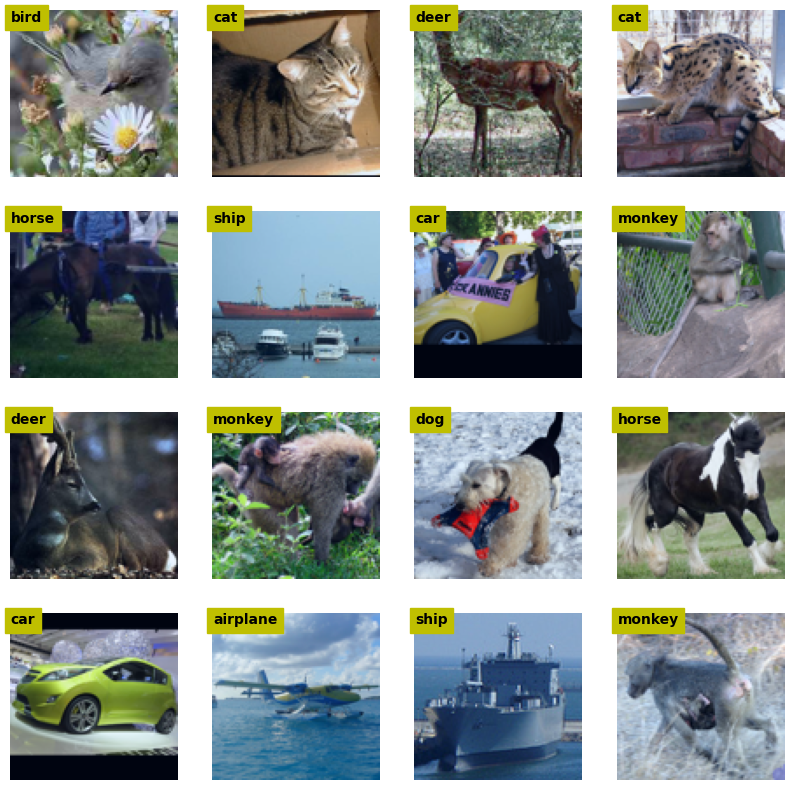

In [5]:
# inspect images

fig, axs = plt.subplots(4, 4, figsize=(10, 10))

for i, ax in enumerate(axs.flatten()):
    
    pic = images.data[i].numpy().transpose((1,2,0))
    pic = pic -np.min(pic) # undo normalization
    pic = pic/np.max(pic)
    
    label = data_train.classes[labels[i]]
    
    ax.imshow(pic)
    ax.text(0, 0, label, ha="left", va="top", fontweight="bold", color="k", backgroundcolor="y")
    ax.axis("off")

In [6]:
def get_resnet(n_outputs=10):
    resnet18 = torchvision.models.resnet18(pretrained=True)

    for p in resnet18.parameters():
        p.requires_grad = False

    # print(resnet18) # we can check that the last layer is called fc and it is Linear(512, 1000)
    # out output is 10-way classification
    resnet18.fc = nn.Linear(512, n_outputs)
    
    return resnet18

resnet18 = get_resnet(10)
summary(resnet18.to(device), (3, 96, 96))

/data/pgcasado/projects/deep-learning/venv/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/data/pgcasado/projects/deep-learning/venv/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 64, 48, 48]           9,408
       BatchNorm2d-2           [-1, 64, 48, 48]             128
              ReLU-3           [-1, 64, 48, 48]               0
         MaxPool2d-4           [-1, 64, 24, 24]               0
            Conv2d-5           [-1, 64, 24, 24]          36,864
       BatchNorm2d-6           [-1, 64, 24, 24]             128
              ReLU-7           [-1, 64, 24, 24]               0
            Conv2d-8           [-1, 64, 24, 24]          36,864
       BatchNorm2d-9           [-1, 64, 24, 24]             128
             ReLU-10           [-1, 64, 24, 24]               0
       BasicBlock-11           [-1, 64, 24, 24]               0
           Conv2d-12           [-1, 64, 24, 24]          36,864
      BatchNorm2d-13           [-1, 64, 24, 24]             128
             ReLU-14           [-1, 64,

In [7]:
def train_one_epoch(model: torch.nn.Module,
                   train_dataloader: torch.utils.data.DataLoader,
                   loss_fn: torch.nn.Module,
                   optimizer: torch.optim.Optimizer,
                   device: torch.device): # Added device
    model.train()
    train_loss = 0.0
    train_accuracy = 0.0
    
    for batch, (X, y) in enumerate(train_dataloader):
        # Move data to the specified device
        X, y = X.to(device), y.to(device)
        
        # Forward pass
        y_pred = model(X)
        loss = loss_fn(y_pred, y)
        train_loss += loss.item()

        _, predicted = torch.max(y_pred.data, 1)
        train_accuracy += (predicted == y).sum().item() / y.size(0) 

        # Backward pass and optimization
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    return train_loss, train_accuracy

def train(model: torch.nn.Module,
          train_dataloader: torch.utils.data.DataLoader,
          test_dataloader: torch.utils.data.DataLoader,
          loss_fn: torch.nn.Module,
          optimizer: torch.optim.Optimizer,
          device: torch.device, # Added device
          epochs: int):
    
    # Move the entire model to the device once at the start
    model.to(device)
    
    losses_epochs = [] 
    train_accuracy_epochs = []
    test_accuracy_epochs = []

    for epoch in range(epochs):
        # Pass device to the epoch function
        train_loss, train_acc = train_one_epoch(model, train_dataloader, loss_fn, optimizer, device)

        avg_train_loss = train_loss / len(train_dataloader)
        avg_train_acc = train_acc / len(train_dataloader)
        losses_epochs.append(avg_train_loss)
        train_accuracy_epochs.append(avg_train_acc)

        # Evaluate on the test set
        model.eval()
        test_accuracy = 0.0
        with torch.no_grad():
            for X, y in test_dataloader:
                # Move test data to device
                X, y = X.to(device), y.to(device)
                y_pred = model(X)

                _, predicted = torch.max(y_pred.data, 1)
                test_accuracy += (predicted == y).sum().item() / y.size(0)

        avg_test_acc = test_accuracy / len(test_dataloader)
        test_accuracy_epochs.append(avg_test_acc)

        print(f"Epoch [{epoch+1}/{epochs}], Train Loss: {avg_train_loss:.4f}, "
              f"Train Accuracy: {avg_train_acc:.4f}, Test Accuracy: {avg_test_acc:.4f}")

    return losses_epochs, train_accuracy_epochs, test_accuracy_epochs

In [ ]:
resnet18 = get_resnet(n_outputs=10)
resnet18.to(device)
loss_fn = nn.CrossEntropyLoss()
#optimizer = torch.optim.SGD(resnet18.parameters(), lr=0.001, momentum=0.9)
optimizer = torch.optim.AdamW(resnet18.parameters(), lr=0.001, weight_decay=0.01)
epochs = 10
losses, train_acc, test_acc = train(resnet18, train_dataloader, test_dataloader, loss_fn, optimizer, device, epochs)

/data/pgcasado/projects/deep-learning/venv/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/data/pgcasado/projects/deep-learning/venv/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch [1/10], Train Loss: 1.1854, Train Accuracy: 0.6160, Test Accuracy: 0.7500
Epoch [2/10], Train Loss: 0.7044, Train Accuracy: 0.7648, Test Accuracy: 0.7746
Epoch [3/10], Train Loss: 0.6281, Train Accuracy: 0.7891, Test Accuracy: 0.7794
Epoch [4/10], Train Loss: 0.6035, Train Accuracy: 0.7935, Test Accuracy: 0.7856
Epoch [5/10], Train Loss: 0.5685, Train Accuracy: 0.8059, Test Accuracy: 0.7869
Epoch [6/10], Train Loss: 0.5289, Train Accuracy: 0.8189, Test Accuracy: 0.7934
Epoch [7/10], Train Loss: 0.5084, Train Accuracy: 0.8309, Test Accuracy: 0.7873
Epoch [8/10], Train Loss: 0.5141, Train Accuracy: 0.8209, Test Accuracy: 0.7903
Epoch [9/10], Train Loss: 0.5014, Train Accuracy: 0.8243, Test Accuracy: 0.7946
Epoch [10/10], Train Loss: 0.4848, Train Accuracy: 0.8301, Test Accuracy: 0.7851


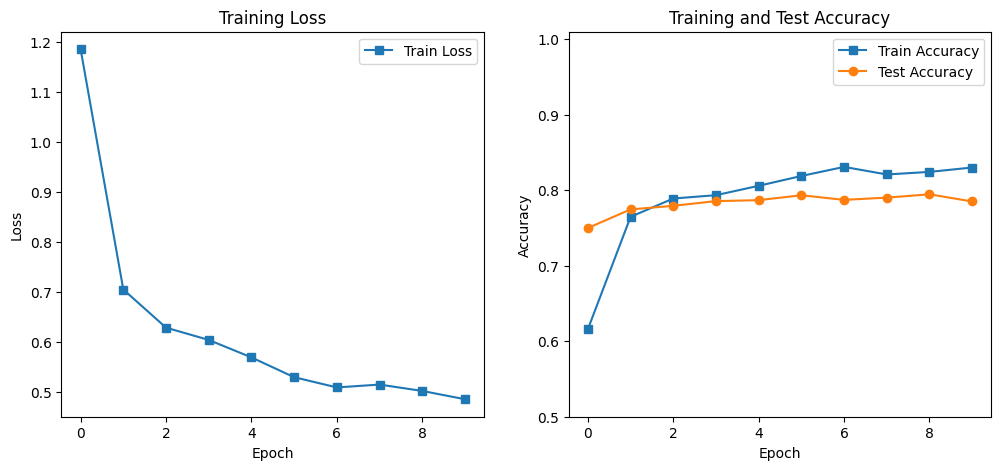

In [13]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].plot(losses, "s-", label='Train Loss')
ax[0].set_title("Training Loss")
ax[0].set_xlabel("Epoch")
ax[0].set_ylabel("Loss")
ax[0].legend()

ax[1].plot(train_acc, "s-", label='Train Accuracy')
ax[1].plot(test_acc, "o-", label='Test Accuracy')
ax[1].set_title("Training and Test Accuracy")
ax[1].set_xlabel("Epoch")
ax[1].set_ylabel("Accuracy")
ax[1].set_ylim(0.5, 1.01)
ax[1].legend()

plt.show()